# Food Waste Reduction Supervised learning Model: Cuisine Profile Predictor

## 1. Introduction
**Recap of the Machine Learning Problem:**
The overarching goal of this project is to build an application that reduces food waste. I pivoted to a **Cuisine Profile Predictor** model which can help reduce food waste by helping users cook with random, expiring ingredients they already have at home .

This model uses supervised learning (Multiclass Classification). When a user inputs a random assortment of leftovers (e.g., tomatoes, basil, garlic, cream), the model analyzes the ingredients and predicts the most likely culinary profile (e.g., Italian). The app can then filter recipe suggestions/come up with recipes to match this cohesive flavor profile, making random leftovers taste like an intentional, coherent meal.

## 2. Data Collection
**Data Source URL:** 
The dataset is the "Recipe Ingredients Dataset" originally sourced from Yummly, available on Kaggle at: `https://www.kaggle.com/datasets/kaggle/recipe-ingredients-dataset?resource=download&select=train.json`

This dataset is highly relevant because it perfectly mirrors the inputs and outputs needed for our app. It contains lists of ingredients (`ingredients` feature) paired with a definitively labeled culinary profile (`cuisine` target label). This allows us to train a supervised learning model easily, categorizing user leftovers.

In [ ]:
%pip install pandas matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip


In [44]:
import pandas as pd
import json

# Assume dataset is in the same directory as this notebook and load the dataset
with open('train.json', 'r') as file:
    data = json.load(file)

df = pd.DataFrame(data)
display(df.head(10))
display(df.info())

,id,cuisine,ingredients
0,10259,greek,"[romaine lettuce, black olives, grape tomatoes..."
1,25693,southern_us,"[plain flour, ground pepper, salt, tomatoes, g..."
2,20130,filipino,"[eggs, pepper, salt, mayonaise, cooking oil, g..."
3,22213,indian,"[water, vegetable oil, wheat, salt]"
4,13162,indian,"[black pepper, shallots, cornflour, cayenne pe..."
5,6602,jamaican,"[plain flour, sugar, butter, eggs, fresh ginge..."
6,42779,spanish,"[olive oil, salt, medium shrimp, pepper, garli..."
7,3735,italian,"[sugar, pistachio nuts, white almond bark, flo..."
8,16903,mexican,"[olive oil, purple onion, fresh pineapple, por..."
9,12734,italian,"[chopped tomatoes, fresh basil, garlic, extra-..."


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39774 entries, 0 to 39773
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           39774 non-null  int64 
 1   cuisine      39774 non-null  object
 2   ingredients  39774 non-null  object
dtypes: int64(1), object(2)
memory usage: 932.3+ KB


None

## 3. Data Preparation and EDA
**Understanding the Data:**
From the initial load, the data is very clean. It contains no "null" or missing values, but the `ingredients` column is a list of strings which cannot be used at TF-IDF

**Required Processing:**
Machine learning models cannot read raw text or Python lists. We need to do two things:
1. **String Joining:** Convert the list of ingredients into a single text string (e.g., `['romaine lettuce', 'olives']` -> `'romaine_lettuce olives'`).
2. **Term Frequency-Inverse Document Frequency (TF-IDF)**. This gives higher mathematical weight to unique ingredients that define a cuisine (like 'soy sauce') and lower weight to common filler ingredients (like 'salt' or 'water').

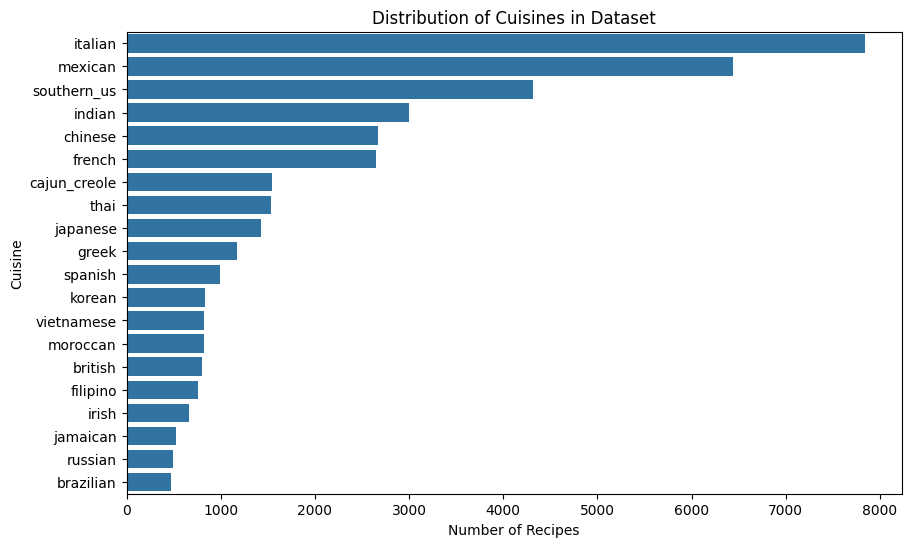

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# EDA: Check the distribution of cuisines
plt.figure(figsize=(10, 6))
sns.countplot(y='cuisine', data=df, order=df['cuisine'].value_counts().index)
plt.title('Distribution of Cuisines in Dataset')
plt.xlabel('Number of Recipes')
plt.ylabel('Cuisine')
plt.show()

**Why we use it**: This creates a bar chart showing how many recipes exist for each cuisine. In this dataset, "Italian" and "Mexican" have thousands of recipes, while "Brazilian" has very few. We need to know this because it creates a Class Imbalance. If a model isn't careful, it might just guess "Italian" every time because, it's the safest bet. To prevent this we need strict evaluation metrics later.

C:\Users\eldri\AppData\Local\Temp\ipykernel_10452\584414378.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='ingredient_count', y='cuisine', data=avg_complexity, palette='viridis')


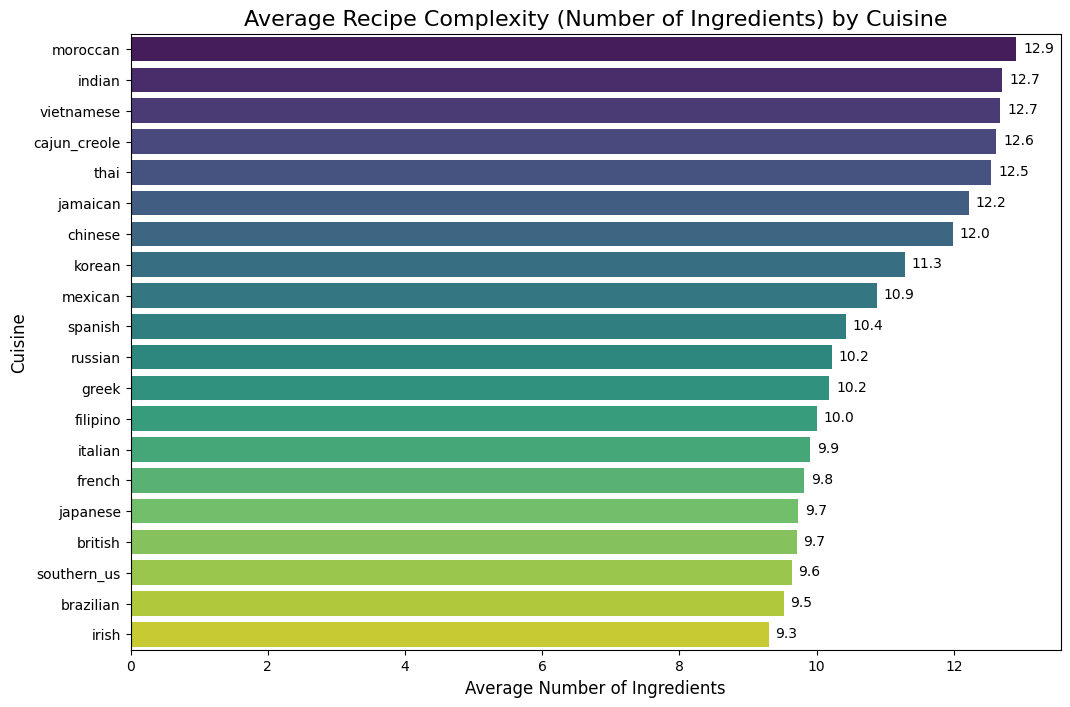

In [46]:
# Average number of ingredients per cuisine
# 1. Calculate the number of ingredients for each recipe
df['ingredient_count'] = df['ingredients'].apply(len)

# 2. Calculate the AVERAGE number of ingredients per cuisine and sort them
avg_complexity = df.groupby('cuisine')['ingredient_count'].mean().sort_values(ascending=False).reset_index()

# 3. Plot a sorted, horizontal bar chart
plt.figure(figsize=(12, 8))
sns.barplot(x='ingredient_count', y='cuisine', data=avg_complexity, palette='viridis')

# 4. Formatting
plt.title('Average Recipe Complexity (Number of Ingredients) by Cuisine', fontsize=16)
plt.xlabel('Average Number of Ingredients', fontsize=12)
plt.ylabel('Cuisine', fontsize=12)

for index, value in enumerate(avg_complexity['ingredient_count']):
    plt.text(value + 0.1, index + 0.1, f'{value:.1f}')

plt.show()

### Why?
- If the model is analyzing a user's leftovers and sees a massive list of 15 ingredients, it can statistically lean toward predicting a complex cuisine (like Indian) rather than a simpler one (like Irish).
- In this case, the recipe complexity does not have massive variance thus it is fine.

In [47]:
# Data Processing Step 1: Convert list of ingredients to a single string separated by spaces
# Replace spaces in each ingredient with an underscore, THEN join them with a space
df['ingredients_str'] = df['ingredients'].apply(lambda x: ' '.join([i.replace(' ', '_') for i in x]))

### Why we use it:
- In the raw JSON dataset, ingredients are stored as a Python list (e.g., ['tomato', 'garlic', 'cream cheese']).
- The TF-IDF algorithm cannot read lists.
- This code loops through every recipe and joins the list into a single, continuous sentence (e.g., "tomato garlic cream_cheese").

In [48]:
# Data Processing Step 2: Define features (X) and target (y)
X = df['ingredients_str']
y = df['cuisine']

# Data Processing Step 3: Train-Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Data Processing Step 4: Vectorization using TF-IDF
tfidf = TfidfVectorizer(max_features=5000) # Limit to top 5000 words for efficiency
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Training feature matrix shape: {X_train_tfidf.shape}")

Training feature matrix shape: (31819, 5000)


### Why we use it:
- TF-IDF stands for Term Frequency-Inverse Document Frequency. It is a mathematical formula that gives a weight/score to every ingredient based on how important it is.
- It gives a low weight to ingredients that appear in almost every recipe (like "salt" or "water") because they don't help identify a specific cuisine.
- It gives a high weight to rare ingredients that are highly specific to certain cuisines (like "soy sauce" or "tortillas").

## 4. Model Training and Evaluation
**Choice of Model:**
We will use **Logistic Regression** specifically configured for multiclass classification. 

**Evaluation Metrics:**
We will use **Accuracy** as our baseline metric, but rely on the **Classification Report (Precision, Recall, F1-Score)**. Because our dataset has class imbalances (e.g., Italian has many more recipes than Brazilian), looking at the F1-score for individual cuisines ensures our model isn't just blindly guessing the most popular class.

In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Initialize and train the Logistic Regression model
# Class weight 'balanced' a machine learning tool used to fix imbalanced datasets. 
# They force the model to pay equal attention to rare and common groups. When a rare group is missed, the model is penalized more heavily
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42) 
model.fit(X_train_tfidf, y_train)

# Make predictions on the testing set
y_pred = model.predict(X_test_tfidf)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 75.08%

Classification Report:
              precision    recall  f1-score   support

   brazilian       0.45      0.67      0.54        84
     british       0.39      0.61      0.47       157
cajun_creole       0.72      0.80      0.76       328
     chinese       0.85      0.80      0.82       510
    filipino       0.53      0.70      0.60       136
      french       0.59      0.65      0.62       550
       greek       0.64      0.76      0.70       249
      indian       0.91      0.86      0.88       602
       irish       0.45      0.65      0.53       151
     italian       0.90      0.75      0.82      1567
    jamaican       0.59      0.75      0.66        91
    japanese       0.80      0.73      0.76       284
      korean       0.77      0.85      0.81       166
     mexican       0.95      0.84      0.89      1336
    moroccan       0.71      0.83      0.76       166
     russian       0.30      0.67      0.41        89
 southern_us       0.80      0.65 

--- STARTING MULTI-MODEL GRID SEARCH OPTIMIZATION ---
Testing multiple models and parameters. This may take a few minutes...

Training and tuning LogisticRegression...
  Best Params: {'C': 10.0, 'class_weight': None}
  Test Accuracy: 77.89% (Took 23.28 seconds)

Training and tuning MultinomialNB...
  Best Params: {'alpha': 0.1}
  Test Accuracy: 74.88% (Took 0.69 seconds)

Training and tuning RandomForest...
  Best Params: {'max_depth': None, 'n_estimators': 100}
  Test Accuracy: 70.95% (Took 118.80 seconds)

----------------------------------------
WINNING MODEL: LogisticRegression with 77.89% accuracy!
----------------------------------------

Optimized Classification Report (LogisticRegression):
              precision    recall  f1-score   support

   brazilian       0.75      0.61      0.67        84
     british       0.52      0.44      0.48       157
cajun_creole       0.77      0.65      0.71       328
     chinese       0.79      0.83      0.81       510
    filipino       0.6

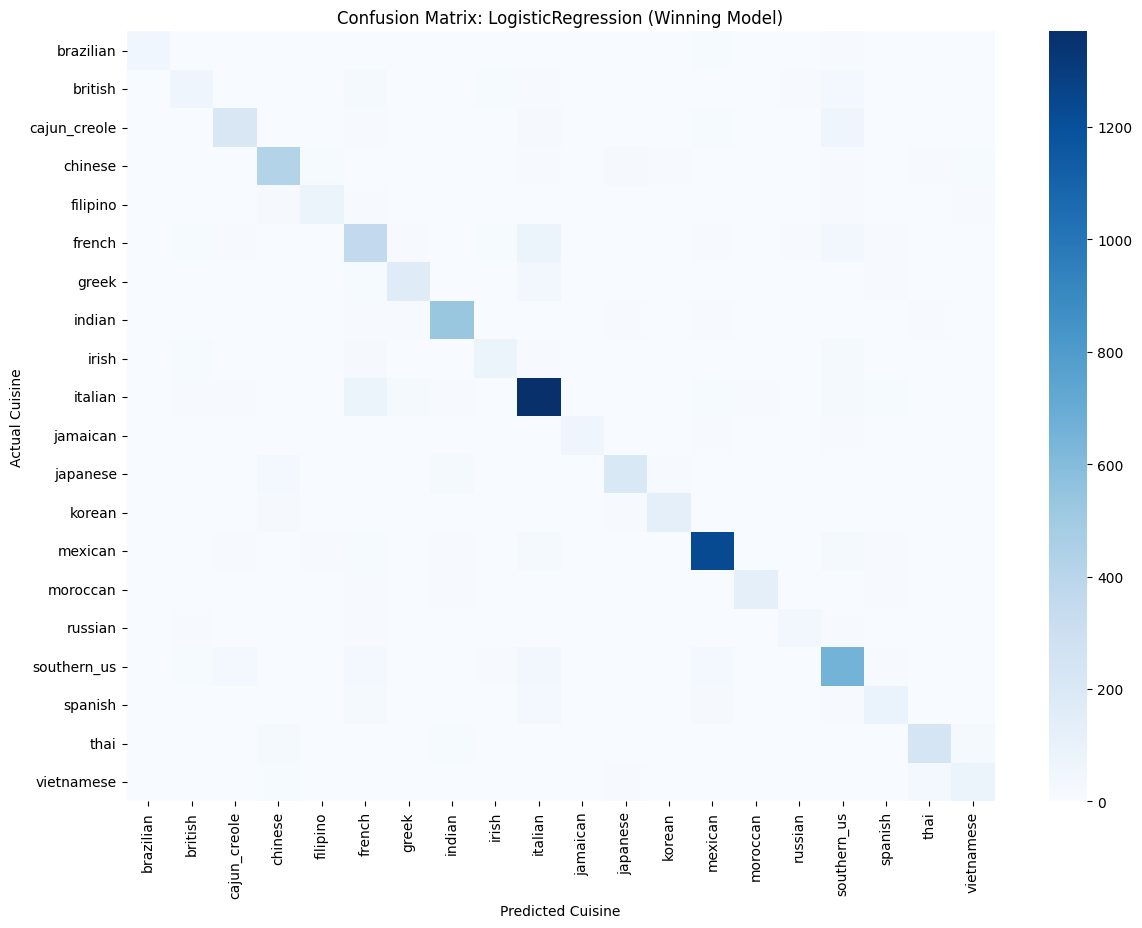

In [53]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import time

print("--- STARTING MULTI-MODEL GRID SEARCH OPTIMIZATION ---")
print("Testing multiple models and parameters. This may take a few minutes...\n")

models = {
    'LogisticRegression': {
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'params': {
            'C': [0.1, 1.0, 10.0],
            'class_weight': [None, 'balanced']
        }
    },
    'MultinomialNB': {
        'model': MultinomialNB(),
        'params': {
            'alpha': [0.1, 0.5, 1.0]
        }
    },
    'RandomForest': {
        'model': RandomForestClassifier(random_state=42),
        # Keeping parameters light so it doesn't take hours to train on a laptop
        'params': {
            'n_estimators': [50, 100],
            'max_depth': [10, 20, None]
        }
    }
}

best_model = None
best_accuracy = 0
best_model_name = ""
model_results = {}

for model_name, config in models.items():
    print(f"Training and tuning {model_name}...")
    start_time = time.time()
    
    grid_search = GridSearchCV(config['model'], config['params'], cv=3, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train_tfidf, y_train)
    
    # Evaluate on test set
    y_pred = grid_search.best_estimator_.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    model_results[model_name] = acc
    
    end_time = time.time()
    print(f"  Best Params: {grid_search.best_params_}")
    print(f"  Test Accuracy: {acc * 100:.2f}% (Took {end_time - start_time:.2f} seconds)\n")
    
    # Keep track of the absolute best model
    if acc > best_accuracy:
        best_accuracy = acc
        best_model = grid_search.best_estimator_
        best_model_name = model_name

print("-" * 40)
print(f"WINNING MODEL: {best_model_name} with {best_accuracy * 100:.2f}% accuracy!")
print("-" * 40)

model = best_model 

y_pred_opt = model.predict(X_test_tfidf)

print(f"\nOptimized Classification Report ({best_model_name}):")
print(classification_report(y_test, y_pred_opt))

# 5. Visual Proof: Confusion Matrix Heatmap for the Winning Model
cm = confusion_matrix(y_test, y_pred_opt, labels=model.classes_)

plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.title(f'Confusion Matrix: {best_model_name} (Winning Model)')
plt.xlabel('Predicted Cuisine')
plt.ylabel('Actual Cuisine')
plt.show()

In [54]:
# Quick Test: Simulating User Input
sample_leftovers = ["tomatoes", "basil", "garlic", "olive oil", "heavy cream", "cheese"]
# sample_leftovers = ["garlic", "salt", "soy sauce", "oil", "testwrong", "cheese", "flour", "sugar", "eggs", "milk"]
sample_leftovers_str = ' '.join([i.replace(' ', '_') for i in sample_leftovers])
sample_vectorized = tfidf.transform([sample_leftovers_str])
predicted_cuisine = model.predict(sample_vectorized)
print(f"\n--- Test Simulation ---")
print(f"User Input: {', '.join(sample_leftovers)}")
print(f"Predicted Cuisine: {predicted_cuisine[0].capitalize()}")


--- Test Simulation ---
User Input: tomatoes, basil, garlic, olive oil, heavy cream, cheese
Predicted Cuisine: Italian


In [55]:
import joblib

# Save the model and the vectorizer to your folder
joblib.dump(model, 'cuisine_predictor_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

print("Success! Your ML Model and Vectorizer are saved and ready for the Web App.")

Success! Your ML Model and Vectorizer are saved and ready for the Web App.
